In [40]:
import sys
from pathlib import Path
from IPython.display import display
from PIL import Image

# paths
sys.path.append(str(Path().resolve().parent.parent))

# lerobot
from lerobot.policies.factory import make_policy, make_pre_post_processors
from lerobot.datasets.utils import build_dataset_frame, combine_feature_dicts
from lerobot.configs.policies import PreTrainedConfig
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.processor.rename_processor import rename_stats
from lerobot.processor import (
    PolicyAction,
    PolicyProcessorPipeline,
    ProcessorStep,
    RobotAction,
    RobotObservation,
    RobotProcessorPipeline,
    make_default_processors,
)

# my code
from robot.robot_config import robot_config
from robot.robot_const import FOLDED_START_POSE
from src.paths import REPO_ROOT, HF_NAME, POLICIES_DIR, EVAL_DIR, DATASETS_DIR
from src.record_extended import record_extended
from src.utils import check_resume

# robot
from robot.robot_config import robot

# yolo
from src.yolo.yolo_lerobot_processor import YoloAnnotateProcessorStep, yolo_preprocess

# magic autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Configure repo:

In [2]:
# ACT policy params
ACT_REPO_NAME     = 'so101_car_pick_and_place-bbox'
ACT_EXPERIMENT_NAME   = 'yolo_v0'
POLICY_CHECKPOINT = '060000'
POLICY_TYPE       = 'act'

# yolo model params
YOLO_REPO_NAME       = 'so101_car_pick_and_place'
YOLO_EXPERIMENT_NAME = 'v0'

Get a robot observation:

In [36]:
robot.connect()
observation = robot.get_observation()
robot.disconnect()

### Test robot observation pipeline

Build the YOLO pre-processor:

In [3]:
# build yolo processor
yolo_model_path = POLICIES_DIR / 'yolo' / YOLO_REPO_NAME / YOLO_EXPERIMENT_NAME / 'best.pt'
yolo_processor = YoloAnnotateProcessorStep(model_path = yolo_model_path, cam_name = 'top_cam')

Build default robot observation processor:

In [ ]:
_, _, robot_observation_processor = make_default_processors()

Intergate both for a unified pre-processor:

In [ ]:
robot_observation_processor.steps.extend([yolo_processor])

Call the robot observation with yolo:

dict_keys(['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos', 'wrist_cam', 'top_cam', 'source_x', 'source_y', 'source_r', 'target_x', 'target_y', 'target_r', 'top_cam_bbox'])


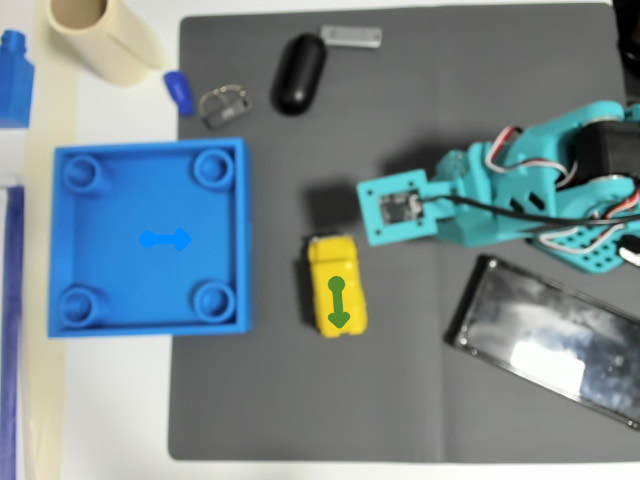

In [38]:
processed_obs = robot_observation_processor(observation)
print(processed_obs.keys())
display(Image.fromarray(processed_obs['top_cam_bbox']))

### Test dataset storage pipeline

In [ ]:
dataset = LeRobotDataset(f"{HF_NAME}/{ACT_REPO_NAME}", root=f"{DATASETS_DIR}/{ACT_REPO_NAME}", video_backend='pyav')
observation_frame = build_dataset_frame(dataset.features, processed_obs, prefix="observation")
print(observation_frame.keys())

Value(False)


### Test policy pipeline

In [6]:
rename_map = {}

In [ ]:
# policy path
policy_path = POLICIES_DIR / POLICY_TYPE / ACT_REPO_NAME / ACT_EXPERIMENT_NAME / "checkpoints" / POLICY_CHECKPOINT / "pretrained_model"
policy_config = PreTrainedConfig.from_pretrained(policy_path)

# build policy preprocessor
preprocessor, _ = make_pre_post_processors(
    policy_cfg             = policy_config,
    pretrained_path        = policy_path,
    dataset_stats          = rename_stats(dataset.meta.stats, rename_map),
    preprocessor_overrides = {
        "device_processor"             : {"device": policy_config.device},
        "rename_observations_processor": {"rename_map": rename_map},
    },
)

In [52]:
observation_frame.keys()

dict_keys(['observation.state', 'observation.images.wrist_cam', 'observation.images.top_cam', 'observation.environment_state'])

In [57]:
preproc_frame = preprocessor(observation_frame)

Value(False)
Value(False)


RuntimeError: value cannot be converted to type uint8 without overflow